In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
import re
import nltk

from nltk.corpus import stopwords  # Importando stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize  # Importando word_tokenize
# import ace_tools as tools

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import textwrap # Ajuste de texto no print

# Baixa os stopwords em inglês (remova se já tiver baixado anteriormente)
nltk.download('stopwords')

nltk.download('wordnet')  # WordNet para lematização
nltk.download('omw-1.4')  # WordNet data for other languages

# from scipy.linalg import triu
from gensim import corpora
# from gensim.models import LdaModel  
from gensim.models.ldamulticore import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel 

import pyLDAvis.gensim
import pyLDAvis

from collections import Counter
import os
import sys
import warnings
import multiprocessing

multiprocessing.set_start_method("spawn", force=True)
# warnings.filterwarnings("ignore", category=DeprecationWarning)
# os.environ["JOBLIB_MULTIPROCESSING"] = "loky"


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mborges/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/mborges/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/mborges/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [3]:
books_rating = pd.read_csv('../data/raw/Books_rating.csv')
books_rating

,Id,Title,Price,User_id,profileName,score,time,summary,text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",4.0,940636800,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,5.0,1095724800,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,5.0,1078790400,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",4.0,1090713600,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",4.0,1107993600,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...
...,...,...,...,...,...,...,...,...,...
2999995,B000NSLVCU,The Idea of History,NaN,NaN,NaN,4.0,937612800,Difficult,"This is an extremely difficult book to digest,..."
2999996,B000NSLVCU,The Idea of History,NaN,A1SMUB9ASL5L9Y,jafrank,4.0,1331683200,Quite good and ahead of its time occasionally,This is pretty interesting. Collingwood seems ...
2999997,B000NSLVCU,The Idea of History,NaN,A2AQMEKZKK5EE4,"L. L. Poulos ""Muslim Mom""",4.0,1180224000,Easier reads of those not well versed in histo...,"This is a good book but very esoteric. ""What i..."
2999998,B000NSLVCU,The Idea of History,NaN,A18SQGYBKS852K,"Julia A. Klein ""knitting rat""",5.0,1163030400,"Yes, it is cheaper than the University Bookstore","My daughter, a freshman at Indiana University,..."


In [4]:
# Conforme observado, é necessário reduzir o número de amostrar no arquivo CSV para que seja capaz fazer o processamento do mesmo.
# O MOTIVO foi observado a falta de processamento pararelo, causando um consumo muito grande de memoria ram o casionando desligamento do kernel do ambiente jupyter notebook. 

In [5]:
# books_rating = books_rating[0:50000] # foi escolhido 
# books_rating

# Selecionando aleatoriamente 50.000 linhas
books_rating = books_rating.sample(n=50000, random_state=42)  # random_state para reprodutibilidade
books_rating

,Id,Title,Price,User_id,profileName,score,time,summary,text
2945667,B0006CR6U4,"A dictionary of the Targumim, the Talmud Babli...",NaN,A303XPDO694V6X,Ariel,4.0,1122163200,Jastrow,Jastrow made a great workthis dictionary can h...
2352586,0897166159,Espresso Coffee: Professional Techniques,NaN,A3780H4TM9RMB8,David barnes,2.0,1356912000,NOT the book,Extremely disappointed by the SHORT length and...
1531260,0736693408,The First King of Shannara (The Sword of Shann...,NaN,A1AX6VPDQQZDPV,M Carlton,5.0,1105574400,Great (what do you expect?),"This, like all of Brook's Shannara series book..."
941910,0395051029,Wuthering Heights (Riverside editions),NaN,A35RQKCCCQ62O0,LadyJ,4.0,1353888000,Satisfied,I enjoyed this classic. I didn't know the stor...
2582125,4770016050,"A Cat, a Man, and Two Women (Japans Modern Wri...",NaN,A2IJQDE1I4SIJT,"David C. Arnold ""master D""",5.0,1167955200,"Ordered 09/02/2006, still on backorder",I would love to read this book. Have accepted ...
...,...,...,...,...,...,...,...,...,...
1333972,B000FO7N6A,Parallel Programming With MPI,13.39,AASVQS2D69KTI,Yoshiro Aoki,5.0,1158883200,Your MPI on-ramp,"I read this book over the past week, covering ..."
62331,B0007EC6H4,The witch of blackbird pond (A Dell yearling b...,NaN,NaN,NaN,5.0,911260800,This heart warming story was a book that I hig...,"This story is a story of love, trust, friends,..."
1229382,0804831432,The Living Tao: Meditations on the Tao Te Chin...,NaN,NaN,NaN,5.0,935366400,Among the best books on Tao Te Ching,"With so many books out there on this subject, ..."
1298893,0195283813,"The New Oxford Annotated Bible, New Revised St...",NaN,NaN,NaN,5.0,930009600,A beautiful edition of the Bible to study and ...,Even though some prefer the comments in the Ha...


# Analise exploratorio para books_rating
Limpeza do dataframe booke_rating

In [7]:
books_rating.dtypes

Id              object
Title           object
Price          float64
User_id         object
profileName     object
score          float64
time             int64
summary         object
text            object
dtype: object

In [8]:
books_rating.isna().sum() # resultdo da contagem de NaN em cada coluna

Id                 0
Title              4
Price          42062
User_id         9187
profileName     9188
score              0
time               0
summary            9
text               0
dtype: int64

In [9]:
""" para o preenchimento da colunas onde há valores valores ausentes, foi escolhido mudar por desconcido e 
    a coluna Price pegar a media de preços dos livros para ser colocado no lugar de NaN
"""

# utilizando o método assing para evistar copias redundantes no dataframe e excevio consumo de mémoria
books_rating = books_rating.assign(
    Price=books_rating['Price'].fillna(books_rating['Price'].mean()),
    User_id=books_rating['User_id'].fillna('UNKNOWN'),
    Title=books_rating['Title'].fillna('UNKNOWN'),
    profileName=books_rating['profileName'].fillna('UNKNOWN'),
    summary=books_rating['summary'].fillna('UNKNOWN'),
    text=books_rating['text'].fillna('UNKNOWN')
)
books_rating.isna().sum() # resultdo da contagem de NaN em cada coluna

Id             0
Title          0
Price          0
User_id        0
profileName    0
score          0
time           0
summary        0
text           0
dtype: int64

In [10]:
books_rating.head(4)

,Id,Title,Price,User_id,profileName,score,time,summary,text
2945667,B0006CR6U4,"A dictionary of the Targumim, the Talmud Babli...",21.886407,A303XPDO694V6X,Ariel,4.0,1122163200,Jastrow,Jastrow made a great workthis dictionary can h...
2352586,0897166159,Espresso Coffee: Professional Techniques,21.886407,A3780H4TM9RMB8,David barnes,2.0,1356912000,NOT the book,Extremely disappointed by the SHORT length and...
1531260,0736693408,The First King of Shannara (The Sword of Shann...,21.886407,A1AX6VPDQQZDPV,M Carlton,5.0,1105574400,Great (what do you expect?),"This, like all of Brook's Shannara series book..."
941910,0395051029,Wuthering Heights (Riverside editions),21.886407,A35RQKCCCQ62O0,LadyJ,4.0,1353888000,Satisfied,I enjoyed this classic. I didn't know the stor...


In [11]:
# Analise exploratoria mais detalhadas
# Converter a coluna 'time' do formato Unix
books_rating['time'] = pd.to_datetime(books_rating['time'], unit='s')
books_rating['time']

2945667   2005-07-24
2352586   2012-12-31
1531260   2005-01-13
941910    2012-11-26
2582125   2007-01-05
             ...    
1333972   2006-09-22
62331     1998-11-17
1229382   1999-08-23
1298893   1999-06-22
2862993   2001-01-23
Name: time, Length: 50000, dtype: datetime64[ns]

In [12]:
# Selecione apenas as colunas numéricas para análise exploratória
books_rating.select_dtypes(include=['float64', 'int64']).describe()

,Price,score
count,50000.000000,50000.000000
mean,21.886407,4.216780
std,11.223910,1.203102
min,1.000000,1.000000
25%,21.886407,4.000000
50%,21.886407,5.000000
75%,21.886407,5.000000
max,665.560000,5.000000


In [13]:
# books_rating.to_csv('../project_A3DATA/csv/books_rating_50k.csv', index=False)

In [14]:
# Verificar as datas mais recentes na coluna
print("\nVerificar as datas mais recentes na coluna")
books_rating['time'].sort_values(ascending=False).head(10)


Verificar as datas mais recentes na coluna


1053966   2013-03-03
941561    2013-03-03
891858    2013-03-03
1573638   2013-03-03
455355    2013-03-03
1356576   2013-03-03
609904    2013-03-03
585463    2013-03-03
1320251   2013-03-03
2655525   2013-03-03
Name: time, dtype: datetime64[ns]

In [15]:
# Verificar as maiores pontuações de avaliação (score) no dataset
print("\nVerificar as maiores pontuações de avaliação (score) no dataset")

books_rating[['score', 'Title', 'time']].sort_values(by='time', ascending=False).head(10)


Verificar as maiores pontuações de avaliação (score) no dataset


,score,Title,time
1053966,5.0,"The Root of Chinese Qigong: Secrets of Health,...",2013-03-03
941561,5.0,Wuthering Heights (Riverside editions),2013-03-03
891858,5.0,Esquire The Rules: A Man's Guide to Life,2013-03-03
1573638,5.0,Moon Lander: How We Developed the Apollo Lunar...,2013-03-03
455355,5.0,Again,2013-03-03
1356576,4.0,A Small Place,2013-03-03
609904,3.0,"The Awakening: Complete, Authoritative Text Wi...",2013-03-03
585463,5.0,Jane Eyre: Complete and Unabridged (Puffin Cla...,2013-03-03
1320251,5.0,Wuthering Heights (Penguin Audiobooks),2013-03-03
2655525,5.0,Empty Land,2013-03-03



Plotando a distribuição das pontuações (score)



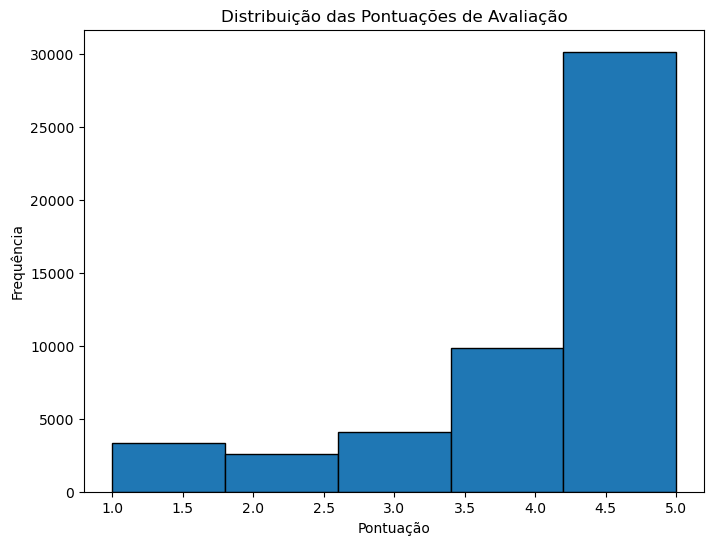

In [16]:
# Plotando a distribuição das pontuações (score)
print("\nPlotando a distribuição das pontuações (score)\n")

plt.figure(figsize=(8, 6))
plt.hist(books_rating['score'], bins=5, edgecolor='black')
plt.title('Distribuição das Pontuações de Avaliação')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')
plt.show();

In [17]:
# Exibir os títulos com mais avaliações
# Contar a quantidade de avaliações por título e ordenar para encontrar os mais avaliados

top_reviewed_titles = books_rating['Title'].value_counts().head(10) # escolhido 10  titulos
top_reviewed_titles_df = top_reviewed_titles.reset_index()
top_reviewed_titles_df.columns = ['Title', 'Review_Count']

print("\nTítulos com mais avaliações")
top_reviewed_titles_df


Títulos com mais avaliações


,Title,Review_Count
0,Pride and Prejudice,345
1,The Hobbit,334
2,Atlas Shrugged,217
3,Wuthering Heights,201
4,The Giver,134
5,Of Mice and Men,120
6,Harry Potter and The Sorcerer's Stone,116
7,The Picture of Dorian Gray,115
8,Great Expectations,114
9,Mere Christianity,104


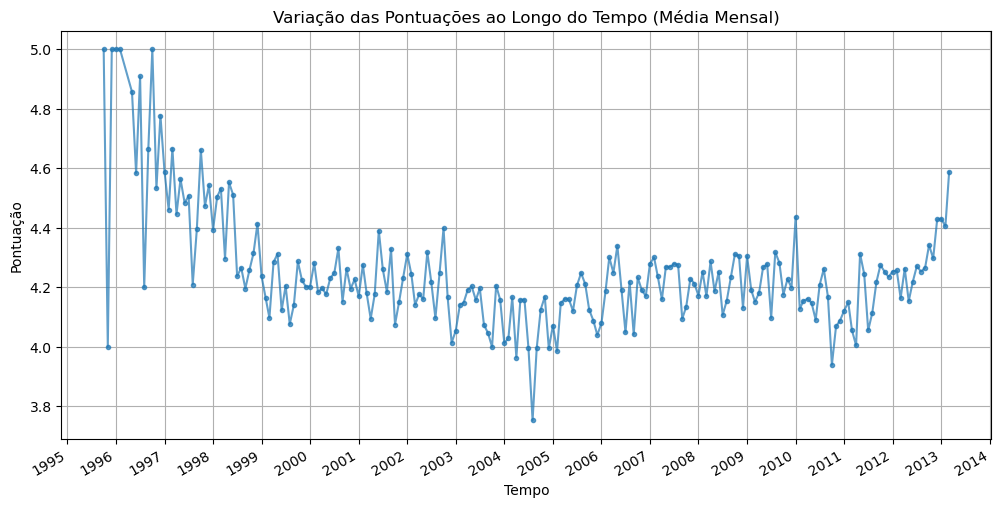

In [18]:
# Ordenar os dados por data para uma análise temporal
data_sorted = books_rating.sort_values(by='time')

# Reduzir a granularidade das datas para a média anual das pontuações
data_grouped = data_sorted.groupby(data_sorted['time'].dt.to_period('M')).agg({'score': 'mean'}).reset_index()
data_grouped['time'] = data_grouped['time'].dt.to_timestamp()  # Converter Period para Timestamp

# Plotando a variação das pontuações ao longo do tempo
plt.figure(figsize=(12, 6))
plt.plot(data_grouped['time'], data_grouped['score'], marker='o', linestyle='-', markersize=3, alpha=0.7)

plt.title('Variação das Pontuações ao Longo do Tempo (Média Mensal)')
plt.xlabel('Tempo')
plt.ylabel('Pontuação')
plt.grid(True)

# Formatando eixos para melhor visualização
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()  # Rotacionar datas para melhor leitura

plt.show()


/tmp/ipykernel_7055/1233687742.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data_sorted['time'].dt.year, y=data_sorted['score'], palette="Set3")


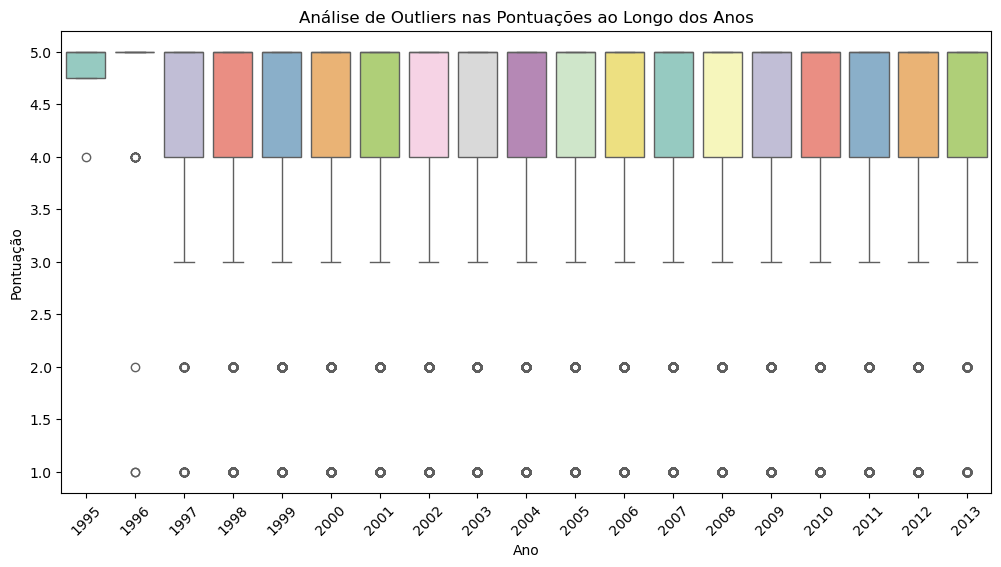

In [19]:
# Analisar outliers nas pontuações ao longo do tempo

# Configurar o tamanho da figura
plt.figure(figsize=(12, 6))

# Criar um boxplot para visualizar outliers nas pontuações ao longo do tempo
sns.boxplot(x=data_sorted['time'].dt.year, y=data_sorted['score'], palette="Set3")
plt.title('Análise de Outliers nas Pontuações ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Pontuação')
plt.xticks(rotation=45)

plt.show();

### O boxplot acima mostra a análise de outliers nas pontuações ao longo dos anos. Ele ajuda a identificar anos com avaliações que se destacam (acima ou abaixo do padrão), indicando períodos de maior variação nas opiniões d os leitores.

In [21]:
# Quais anos tiveram mais avaliações baixas?

# Filtrar as avaliações baixas (definidas como pontuações menores ou iguais a 2) e contar por ano
low_scores = books_rating[books_rating['score'] <= 2]
low_scores_per_year = low_scores['time'].dt.year.value_counts().sort_index()

# Exibir os anos com maior quantidade de avaliações baixas
low_scores_per_year_df = low_scores_per_year.reset_index()
low_scores_per_year_df.columns = ['Year', 'Low_Score_Count']

low_scores_per_year_df.head(5)

,Year,Low_Score_Count
0,1996,3
1,1997,59
2,1998,219
3,1999,510
4,2000,420


In [22]:
# Remove caracteres especiais, pontuação e números, e converte para letras minúsculas da coluna 'summary'

books_rating['cleaned_summary'] = books_rating['summary'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x).lower()) 

# Remove caracteres especiais, pontuação e números, e converte para letras minúsculas na coluna 'text'
books_rating['cleaned_text'] = books_rating['text'].astype(str).apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x).lower())

# Exibe as colunas originais e as colunas limpas para verificação
books_rating[['summary', 'cleaned_summary', 'text', 'cleaned_text']].head(8)


,summary,cleaned_summary,text,cleaned_text
2945667,Jastrow,jastrow,Jastrow made a great workthis dictionary can h...,jastrow made a great workthis dictionary can h...
2352586,NOT the book,not the book,Extremely disappointed by the SHORT length and...,extremely disappointed by the short length and...
1531260,Great (what do you expect?),great what do you expect,"This, like all of Brook's Shannara series book...",this like all of brooks shannara series books ...
941910,Satisfied,satisfied,I enjoyed this classic. I didn't know the stor...,i enjoyed this classic i didnt know the story ...
2582125,"Ordered 09/02/2006, still on backorder",ordered still on backorder,I would love to read this book. Have accepted ...,i would love to read this book have accepted s...
790281,gestalt!,gestalt,"bless you! lol... sorry, but you just have to ...",bless you lol sorry but you just have to read ...
1452582,Well Done!!!!,well done,"Thank you, Dr. Manny. This book was such an in...",thank you dr manny this book was such an inter...
628780,Great Insight into Balkans,great insight into balkans,For anyone living in or traveling to the Balka...,for anyone living in or traveling to the balka...


In [23]:
# Define os stopwords em inglês
stop_words = set(stopwords.words('english'))

# Remove stopwords da coluna 'cleaned_summary'
books_rating['cleaned_summary_no_stopwords'] = books_rating['cleaned_summary'].apply(
    lambda x: ' '.join([word for word in str(x).split() if word not in stop_words])
)

# Remove stopwords da coluna 'cleaned_text'
books_rating['cleaned_text_no_stopwords'] = books_rating['cleaned_text'].apply(
    lambda x: ' '.join([word for word in str(x).split() if word not in stop_words])
)

# Exibir as colunas com stopwords e  sem stopwords para verificação
books_rating[['cleaned_summary', 'cleaned_summary_no_stopwords', 'cleaned_text', 'cleaned_text_no_stopwords']].head()

,cleaned_summary,cleaned_summary_no_stopwords,cleaned_text,cleaned_text_no_stopwords
2945667,jastrow,jastrow,jastrow made a great workthis dictionary can h...,jastrow made great workthis dictionary help le...
2352586,not the book,book,extremely disappointed by the short length and...,extremely disappointed short length cursory in...
1531260,great what do you expect,great expect,this like all of brooks shannara series books ...,like brooks shannara series books wonderful gl...
941910,satisfied,satisfied,i enjoyed this classic i didnt know the story ...,enjoyed classic didnt know story prior reading...
2582125,ordered still on backorder,ordered still backorder,i would love to read this book have accepted s...,would love read book accepted slip delivery am...


In [24]:
# Realizando a tokenização nas colunas de texto limpo e sem stopwords
books_rating['tokenized_summary'] = books_rating['cleaned_summary_no_stopwords'].apply(lambda x: x.split())
books_rating['tokenized_text']    = books_rating['cleaned_text_no_stopwords'].apply(lambda x: x.split())

# Exibindo as colunas com tokens e já tokenizadas para verificação
books_rating[['cleaned_summary_no_stopwords', 'tokenized_summary', 'cleaned_text_no_stopwords', 'tokenized_text']].head(6)

,cleaned_summary_no_stopwords,tokenized_summary,cleaned_text_no_stopwords,tokenized_text
2945667,jastrow,[jastrow],jastrow made great workthis dictionary help le...,"[jastrow, made, great, workthis, dictionary, h..."
2352586,book,[book],extremely disappointed short length cursory in...,"[extremely, disappointed, short, length, curso..."
1531260,great expect,"[great, expect]",like brooks shannara series books wonderful gl...,"[like, brooks, shannara, series, books, wonder..."
941910,satisfied,[satisfied],enjoyed classic didnt know story prior reading...,"[enjoyed, classic, didnt, know, story, prior, ..."
2582125,ordered still backorder,"[ordered, still, backorder]",would love read book accepted slip delivery am...,"[would, love, read, book, accepted, slip, deli..."
790281,gestalt,[gestalt],bless lol sorry read freaks love everything st...,"[bless, lol, sorry, read, freaks, love, everyt..."


In [25]:
# Inicializando o Stemmer e o Lemmatizer para inglês
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Aplicando lematização e stemming nos tokens de 'tokenized_summary' e 'tokenized_text'
books_rating['stemmed_summary'] = books_rating['tokenized_summary'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])
books_rating['stemmed_text']    = books_rating['tokenized_text'].apply(lambda tokens: [stemmer.stem(token) for token in tokens])

# Exibindo as colunas com tokens lematizados e reduzidos
books_rating[['tokenized_summary', 'stemmed_summary', 'tokenized_text', 'stemmed_text']].head()

,tokenized_summary,stemmed_summary,tokenized_text,stemmed_text
2945667,[jastrow],[jastrow],"[jastrow, made, great, workthis, dictionary, h...","[jastrow, made, great, workthi, dictionari, he..."
2352586,[book],[book],"[extremely, disappointed, short, length, curso...","[extrem, disappoint, short, length, cursori, i..."
1531260,"[great, expect]","[great, expect]","[like, brooks, shannara, series, books, wonder...","[like, brook, shannara, seri, book, wonder, gl..."
941910,[satisfied],[satisfi],"[enjoyed, classic, didnt, know, story, prior, ...","[enjoy, classic, didnt, know, stori, prior, re..."
2582125,"[ordered, still, backorder]","[order, still, backord]","[would, love, read, book, accepted, slip, deli...","[would, love, read, book, accept, slip, delive..."


In [26]:
# Juntando todos os tokens da coluna 'stemmed_text' para análise de frequência
all_stemmed_words = [word for tokens in books_rating['stemmed_text'] for word in tokens]

# Contando a frequência de cada palavra
word_frequency = Counter(all_stemmed_words)

# Convertendo para DataFrame para visualização
word_frequency_df = pd.DataFrame(word_frequency.items(), columns=['word', 'frequency']).sort_values(by='frequency', ascending=False)

# Exibindo o DataFrame de frequência de palavras ao usuário

print("\nAnalisar frequência de palavras no texto\n")
word_frequency_df


Analisar frequência de palavras no texto



,word,frequency
84,book,105272
136,read,50797
14,one,31155
100,stori,24518
51,like,22246
...,...,...
71528,technicolour,1
71527,westerncentr,1
71526,overcont,1
71525,windowsmi,1


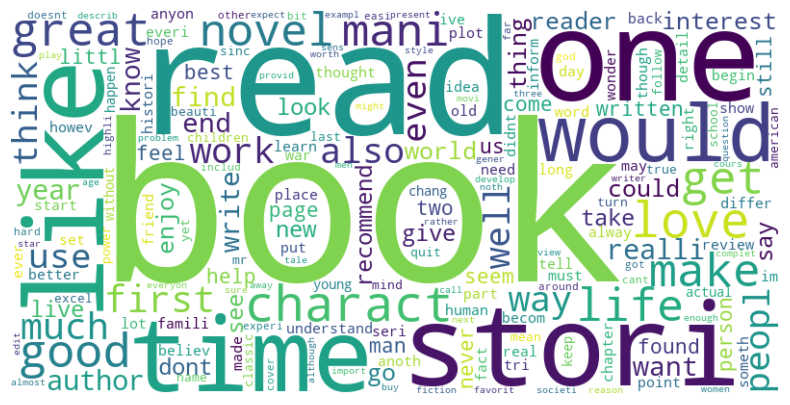

In [27]:
# Gerando a nuvem de palavras com base nas frequências
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_frequency)

# Exibindo a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

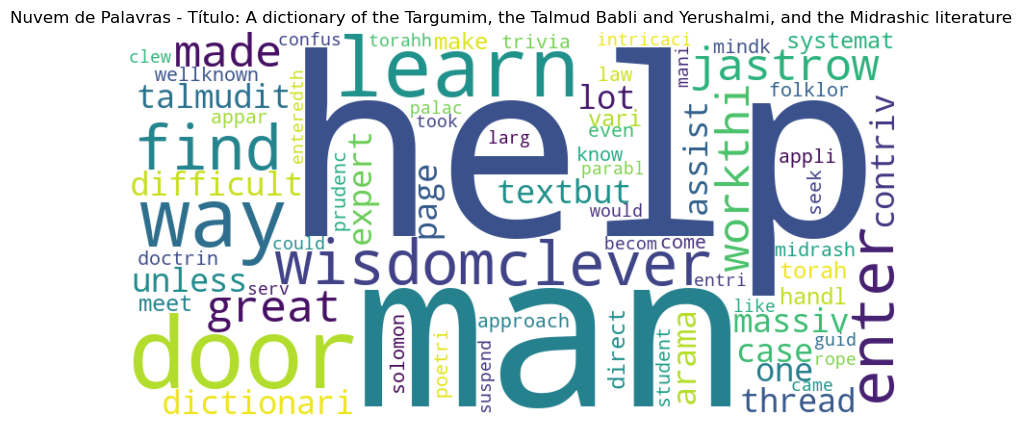

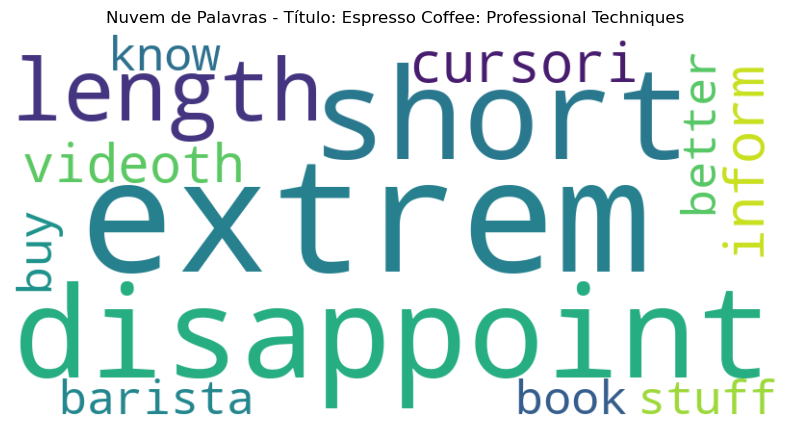

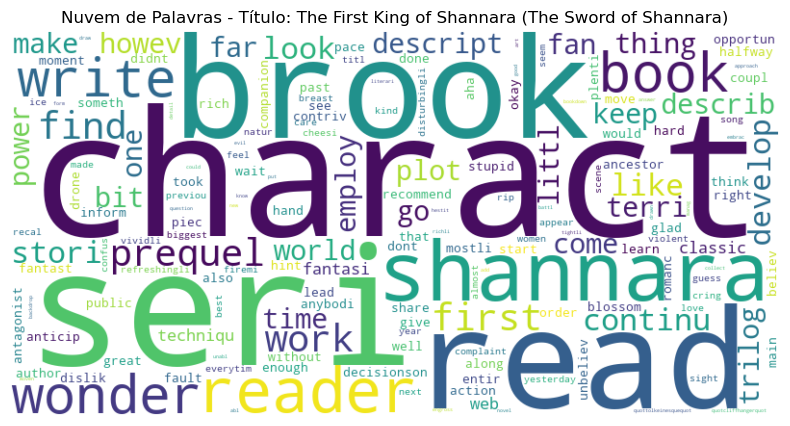

In [28]:
# Criando uma nuvem de palavras por título de livro
# Vamos agrupar os dados por título e gerar uma nuvem para cada um

# Selecionando um título de exemplo para visualização (se houver muitos títulos)
example_titles = books_rating['Title'].unique()[:3]  # Selecionando apenas 3 títulos para exemplo

# Gerando e exibindo a nuvem de palavras para cada título selecionado
for title in example_titles:
    # Filtrando as palavras do texto stemmed para o título específico
    words = [word for tokens in books_rating[books_rating['Title'] == title]['stemmed_text'] for word in tokens]
    word_freq = Counter(words)
    
    # Gerando a nuvem de palavras para o título
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    
    # Exibindo a nuvem de palavras
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Nuvem de Palavras - Título: {title}")
    plt.show()


In [29]:
"""
Para realizar uma análise de sentimento nos resumos ou descrições dos livros, é utlizado a  biblioteca TextBlob.
A TextBlob calcula o sentimento de cada texto, retornando uma polaridade que varia de -1 (muito negativo) a +1 (muito positivo)
"""

# Aplicando a análise de sentimento diretamente nos resumos limpos e sem stopwords
books_rating['summary_sentiment'] = books_rating['cleaned_summary_no_stopwords'].apply(lambda text: TextBlob(text).sentiment.polarity)

# Exibindo o DataFrame com o sentimento dos resumos
print('\nExibindo o DataFrame com o sentimento dos resumos\n')
books_rating[['Title', 'cleaned_summary_no_stopwords', 'summary_sentiment']].head(6)


Exibindo o DataFrame com o sentimento dos resumos



,Title,cleaned_summary_no_stopwords,summary_sentiment
2945667,"A dictionary of the Targumim, the Talmud Babli...",jastrow,0.0
2352586,Espresso Coffee: Professional Techniques,book,0.0
1531260,The First King of Shannara (The Sword of Shann...,great expect,0.8
941910,Wuthering Heights (Riverside editions),satisfied,0.5
2582125,"A Cat, a Man, and Two Women (Japans Modern Wri...",ordered still backorder,0.0
790281,More Than Human,gestalt,0.0


In [30]:
# Filtrando os resumos que possuem sentimento negativo
negative_summaries_df = books_rating[books_rating['summary_sentiment'] < 0][['Title', 'cleaned_summary_no_stopwords', 'summary_sentiment']]
print("\nResumos com Sentimento Negativo\n")

negative_summaries_df.head(4)


Resumos com Sentimento Negativo



,Title,cleaned_summary_no_stopwords,summary_sentiment
2661709,Prince Of The City,companion book dark prince,-0.150000
76037,Right to Life: And 2 New Stories,frightening thoughtprovoking,-0.500000
1975850,A History of Women's Seclusion in the Middle E...,bit dull,-0.291667
1792926,Incident at Badamya,expected,-0.100000


In [31]:
# Agrupe sentimentos por pontuação de livros

# Agrupando a média dos sentimentos por pontuação dos livros
sentiment_by_score_df = books_rating.groupby('score')['summary_sentiment'].mean().reset_index()

print("\nGrupo de sentimentos por pontuação de livros\n")
sentiment_by_score_df


Grupo de sentimentos por pontuação de livros



,score,summary_sentiment
0,1.0,-0.124565
1,2.0,-0.006536
2,3.0,0.142507
3,4.0,0.249742
4,5.0,0.313420


In [32]:
# Criando um dicionário e uma matriz de frequência para a coluna 'stemmed_text'

dictionary = corpora.Dictionary(books_rating['stemmed_text'])
corpus = [dictionary.doc2bow(text) for text in books_rating['stemmed_text']]

# Treinando o modelo LDA com LdaMulticore usando 20 tópicos para mais precisão
lda_model = LdaMulticore(corpus, num_topics=10, id2word=dictionary, passes=10, random_state=42, workers=4)

# Exibindo os principais tópicos identificados
topics = lda_model.print_topics(num_words=5)
for topic in topics:
    print(topic,"\n")

# Avaliando a coerência dos tópicos
coherence_model = CoherenceModel(model=lda_model, texts=books_rating['stemmed_text'], dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()

print(f"\nCoerência dos Tópicos: {coherence_score}\n\n")

(0, '0.009*"stori" + 0.008*"novel" + 0.007*"one" + 0.006*"life" + 0.005*"man"') 

(1, '0.064*"book" + 0.042*"read" + 0.017*"love" + 0.013*"stori" + 0.013*"one"') 

(2, '0.008*"book" + 0.008*"prayer" + 0.007*"bradburi" + 0.006*"poirot" + 0.005*"ray"') 

(3, '0.013*"book" + 0.008*"one" + 0.007*"read" + 0.007*"work" + 0.006*"god"') 

(4, '0.023*"book" + 0.009*"year" + 0.009*"dog" + 0.008*"music" + 0.007*"listen"') 

(5, '0.027*"book" + 0.014*"read" + 0.012*"charact" + 0.012*"like" + 0.012*"stori"') 

(6, '0.008*"book" + 0.007*"american" + 0.007*"war" + 0.006*"histori" + 0.006*"polit"') 

(7, '0.007*"ship" + 0.007*"sea" + 0.006*"vampir" + 0.005*"captain" + 0.005*"whale"') 

(8, '0.023*"book" + 0.006*"use" + 0.006*"one" + 0.005*"work" + 0.005*"help"') 

(9, '0.054*"book" + 0.012*"read" + 0.011*"use" + 0.008*"good" + 0.008*"one"') 


Coerência dos Tópicos: 0.3563985866085818




In [33]:
# Visualização com pyLDAvis
lda_display = pyLDAvis.gensim.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.display(lda_display)

/home/mborges/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7055) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/mborges/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7055) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/mborges/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7055) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/mborges/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=7055) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/mborges/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/b

## <br/><br/>Os principais tópicos identificados pelo modelo LDA para os livros incluem conjuntos de palavras frequentemente associadas, idicando possíveis temas. Abaixo é indentificado cinco tópicos principais:

In [35]:
# Extraindo os tópicos para cada documento (livro) no corpus
doc_topics = [lda_model.get_document_topics(bow) for bow in corpus]

# Criando uma lista com o tópico mais relevante (de maior peso) para cada livro
book_topics = []
for doc_topic in doc_topics:
    # Ordena os tópicos do documento pela relevância e pega o tópico mais relevante
    dominant_topic = sorted(doc_topic, key=lambda x: -x[1])[0][0]
    book_topics.append(dominant_topic)

# Adicionando os tópicos dominantes aos dados
books_rating['Dominant_Topic'] = book_topics

# Exibindo os títulos e seus tópicos dominantes
books_rating[['Title', 'Dominant_Topic']].head(8)


,Title,Dominant_Topic
2945667,"A dictionary of the Targumim, the Talmud Babli...",3
2352586,Espresso Coffee: Professional Techniques,9
1531260,The First King of Shannara (The Sword of Shann...,5
941910,Wuthering Heights (Riverside editions),1
2582125,"A Cat, a Man, and Two Women (Japans Modern Wri...",9
790281,More Than Human,1
1452582,The Checklist: How to Identify True Medical Ad...,8
628780,Black lamb and grey falcon: A journey through ...,1


<Figure size 1400x1000 with 0 Axes>

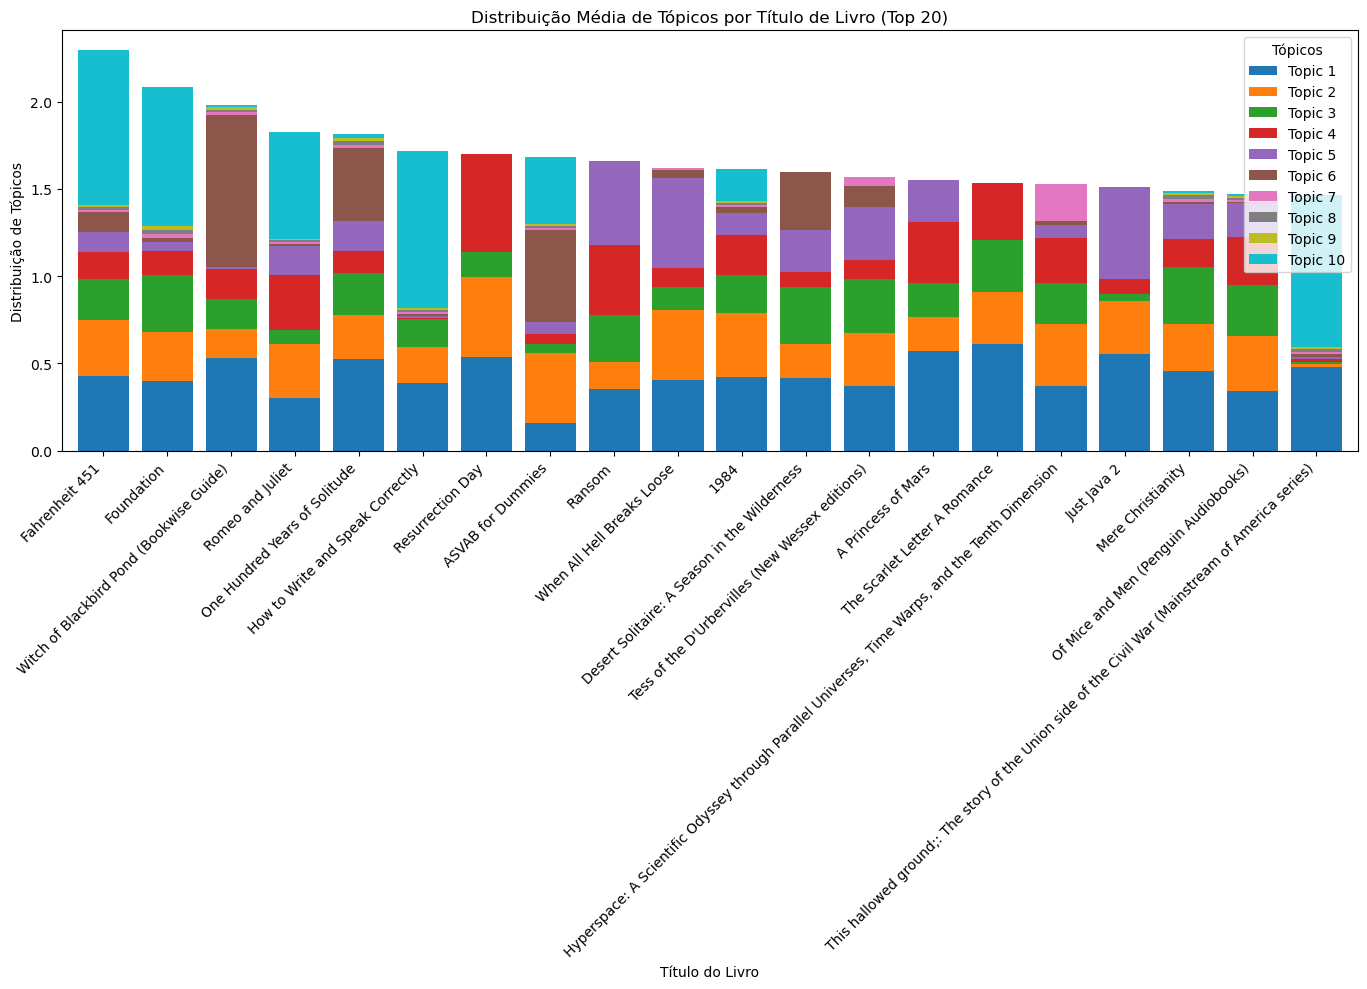

In [36]:
# Obter a distribuição de tópicos para cada documento no corpus
topic_distributions = [lda_model.get_document_topics(bow) for bow in corpus]

# Converter as distribuições de tópicos em um DataFrame para facilitar a visualização
topic_dist_df = pd.DataFrame([[topic[1] for topic in doc] for doc in topic_distributions])
topic_dist_df.columns = [f'Topic {i+1}' for i in range(topic_dist_df.shape[1])]
topic_dist_df['Title'] = books_rating['Title']

# Calculando a média dos tópicos por livro
average_topic_dist = topic_dist_df.groupby('Title').mean()

# Selecionando os 20 títulos com maior distribuição de tópicos para visualização
top_titles = average_topic_dist.sum(axis=1).nlargest(20).index
average_topic_dist_top = average_topic_dist.loc[top_titles]

# Visualizando a distribuição média dos tópicos por título de livro
plt.figure(figsize=(14, 10))
average_topic_dist_top.plot(kind='bar', stacked=True, figsize=(14, 10), width=0.8)
plt.title("Distribuição Média de Tópicos por Título de Livro (Top 20)")
plt.xlabel("Título do Livro")
plt.ylabel("Distribuição de Tópicos")
plt.legend(title="Tópicos")
plt.xticks(rotation=45, ha="right")  
plt.tight_layout()
plt.show();


In [37]:
texto = """Aqui estão os primeiros resultados dos livros agrupados por similaridade, com cada título associado a um cluster específico (de 0 a 4). 
        Esse agrupamento indica quais livros possuem conteúdo semelhante, conforme analisado pelo modelo K-Means usando TF-IDF."""

texto_ajustado = textwrap.fill(texto, width=60)


# Convertendo a coluna 'stemmed_text' para uma lista de strings, unindo tokens com espaço
documents = [" ".join(text) if isinstance(text, list) else text for text in books_rating['stemmed_text']]

# Aplicando o TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

# Definindo o número de clusters e aplicando o KMeans
num_clusters = 5  # Podemos ajustar este número conforme necessário

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
books_rating['Cluster'] = kmeans.fit_predict(tfidf_matrix)

# Exibindo os títulos dos livros com os clusters atribuídos
df_clustered = books_rating[['Title', 'Cluster', 'text']]

print(texto_ajustado,"\n")
df_clustered.head(6)

Aqui estão os primeiros resultados dos livros agrupados por
similaridade, com cada título associado a um cluster
específico (de 0 a 4).          Esse agrupamento indica
quais livros possuem conteúdo semelhante, conforme analisado
pelo modelo K-Means usando TF-IDF. 



,Title,Cluster,text
2945667,"A dictionary of the Targumim, the Talmud Babli...",1,Jastrow made a great workthis dictionary can h...
2352586,Espresso Coffee: Professional Techniques,3,Extremely disappointed by the SHORT length and...
1531260,The First King of Shannara (The Sword of Shann...,4,"This, like all of Brook's Shannara series book..."
941910,Wuthering Heights (Riverside editions),2,I enjoyed this classic. I didn't know the stor...
2582125,"A Cat, a Man, and Two Women (Japans Modern Wri...",3,I would love to read this book. Have accepted ...
790281,More Than Human,0,"bless you! lol... sorry, but you just have to ..."


In [38]:
# Obtenção dos termos principais para cada cluster com base nos centróides do K-Means

# Cada linha em cluster_centers_ é um centróide de cluster com os pesos dos termos
terms = tfidf_vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # Ordena os índices dos termos por peso

# Coletando os principais termos para cada cluster
top_terms_per_cluster = {}
for i in range(num_clusters):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]  # Pega os 10 termos mais representativos
    top_terms_per_cluster[f'Cluster {i}'] = top_terms

# Convertendo para DataFrame para melhor visualização
top_terms_df = pd.DataFrame.from_dict(top_terms_per_cluster, orient='index', columns=[f'Term {i+1}' for i in range(10)])

# Exibindo a tabela com os termos principais de cada cluster
top_terms_df


,Term 1,Term 2,Term 3,Term 4,Term 5,Term 6,Term 7,Term 8,Term 9,Term 10
Cluster 0,love,book,read,stori,one,great,like,time,charact,good
Cluster 1,book,life,one,peopl,read,world,time,live,like,us
Cluster 2,book,read,like,one,time,good,enjoy,realli,would,great
Cluster 3,book,use,great,good,read,one,inform,help,recommend,get
Cluster 4,stori,novel,charact,book,read,one,like,plot,time,end


In [39]:
# Preparando os documentos para o modelo Doc2Vec
documents = [TaggedDocument(words=" ".join(text).split(), tags=[str(i)]) for i, text in enumerate(books_rating['stemmed_text'])]

# Treinando o modelo Doc2Vec para criar embeddings de cada livro
doc2vec_model = Doc2Vec(documents, vector_size=50, window=2, min_count=1, epochs=40, seed=42)

# Extraindo os vetores para cada livro
book_embeddings = np.array([doc2vec_model.dv[str(i)] for i in range(len(books_rating))])

# Calculando a similaridade de cosseno entre os livros
similarity_matrix = cosine_similarity(book_embeddings)

# Transformando a matriz de similaridade em um DataFrame para facilitar a análise
similarity_df = pd.DataFrame(similarity_matrix, index=books_rating['Title'], columns=books_rating['Title'])

# Exibindo uma amostra da matriz de similaridade
similarity_df.iloc[:10, :10]  # Exibindo apenas uma parte para evitar excesso de dados


Title,"A dictionary of the Targumim, the Talmud Babli and Yerushalmi, and the Midrashic literature",Espresso Coffee: Professional Techniques,The First King of Shannara (The Sword of Shannara),Wuthering Heights (Riverside editions),"A Cat, a Man, and Two Women (Japans Modern Writers)",More Than Human,The Checklist: How to Identify True Medical Advice When,Black lamb and grey falcon: A journey through Yugoslavia,"Two Crazy Pigs (Hello Reader, Level 2)",Love You Forever
Title,,,,,,,,,,
"A dictionary of the Targumim, the Talmud Babli and Yerushalmi, and the Midrashic literature",1.000000,0.099355,0.096135,0.070799,0.004924,0.027100,0.267668,0.003015,0.208539,0.028110
Espresso Coffee: Professional Techniques,0.099355,1.000000,0.139585,0.383000,0.245660,0.488866,0.216237,0.271276,0.478336,0.116089
The First King of Shannara (The Sword of Shannara),0.096135,0.139585,1.000000,0.365783,0.225044,0.085395,-0.143214,0.101979,0.260403,0.357395
Wuthering Heights (Riverside editions),0.070799,0.383000,0.365783,1.000000,0.328232,0.194397,0.216276,0.230944,0.485302,0.197932
"A Cat, a Man, and Two Women (Japans Modern Writers)",0.004924,0.245660,0.225044,0.328232,1.000000,0.121186,0.122376,0.037295,0.264816,0.246224
More Than Human,0.027100,0.488866,0.085395,0.194397,0.121186,1.000000,0.382460,0.216452,0.410133,0.464326
The Checklist: How to Identify True Medical Advice When,0.267668,0.216237,-0.143214,0.216276,0.122376,0.382460,1.000000,0.314848,0.379222,0.146456
Black lamb and grey falcon: A journey through Yugoslavia,0.003015,0.271276,0.101979,0.230944,0.037295,0.216452,0.314848,1.000000,0.315781,0.125087
"Two Crazy Pigs (Hello Reader, Level 2)",0.208539,0.478336,0.260403,0.485302,0.264816,0.410133,0.379222,0.315781,1.000000,0.516964


/tmp/ipykernel_7055/3695426121.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")


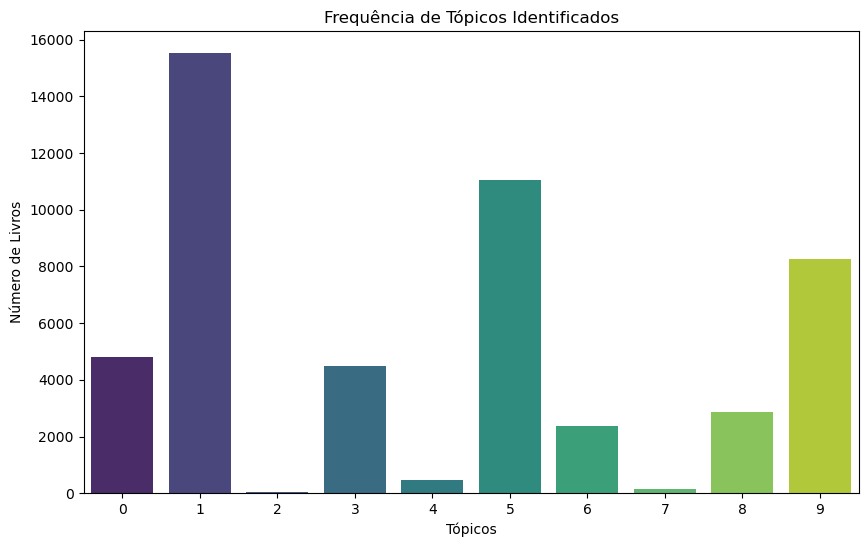

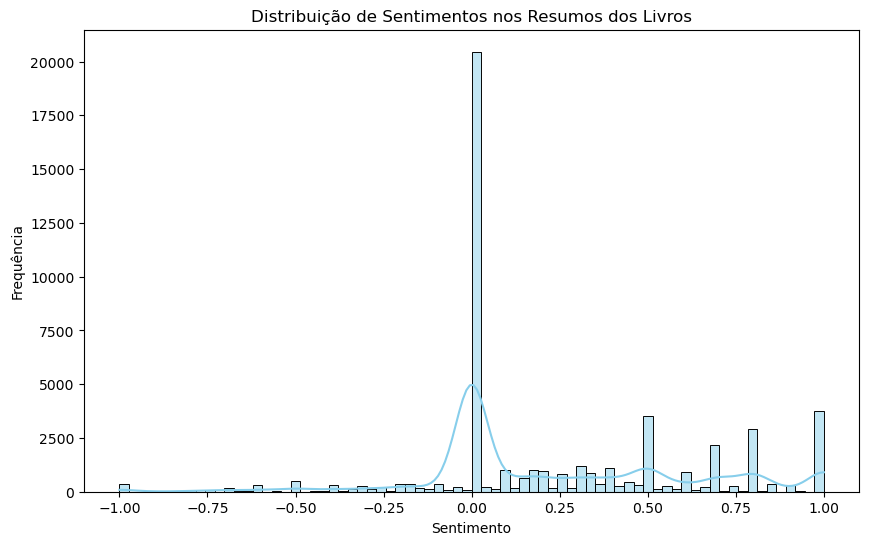

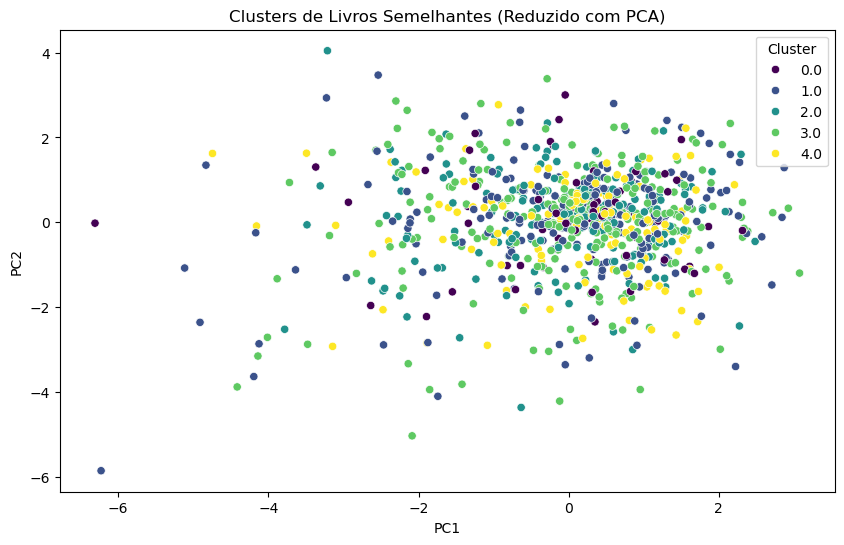

In [40]:
# Visualização 1: Frequência de Tópicos
if 'Dominant_Topic' in books_rating.columns:
    topic_counts = books_rating['Dominant_Topic'].value_counts()
    plt.figure(figsize=(10, 6))
    sns.barplot(x=topic_counts.index, y=topic_counts.values, palette="viridis")
    plt.title("Frequência de Tópicos Identificados")
    plt.xlabel("Tópicos")
    plt.ylabel("Número de Livros")
    plt.show()

# Visualização 2: Distribuição de Sentimentos
if 'summary_sentiment' in books_rating.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(books_rating['summary_sentiment'], kde=True, color='skyblue')
    plt.title("Distribuição de Sentimentos nos Resumos dos Livros")
    plt.xlabel("Sentimento")
    plt.ylabel("Frequência")
    plt.show()

# Visualização 3: Clusters de Livros Semelhantes (PCA)
if 'Cluster' in books_rating.columns:
    # Reduzindo a dimensionalidade com PCA para visualização
    pca = PCA(n_components=2)
    book_embeddings_2d = pca.fit_transform(book_embeddings)

    # Criando um DataFrame para visualização
    cluster_df = pd.DataFrame(book_embeddings_2d, columns=['PC1', 'PC2'])
    cluster_df['Cluster'] = books_rating['Cluster']

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=cluster_df, palette="viridis", legend="full")
    plt.title("Clusters de Livros Semelhantes (Reduzido com PCA)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.show();
